In [2]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers,utils

 

# 1. Load Dataset

In [3]:
image_width = 64
image_height = 64
image_batch = 32

train_ds = utils.image_dataset_from_directory(
    "./dataset/train",
    image_size=(image_width, image_height),
    batch_size=image_batch
)

val_ds = utils.image_dataset_from_directory(
    "./dataset/train",
    image_size=(image_width, image_height),
    batch_size=image_batch
)

test_ds = utils.image_dataset_from_directory(
    "./dataset/test",
    image_size=(image_width, image_height),
    batch_size=image_batch
)

Found 4662 files belonging to 3 classes.
Found 4662 files belonging to 3 classes.
Found 215 files belonging to 3 classes.


In [4]:
X_train = np.concatenate([x for x, y in train_ds])
y_train = np.concatenate([y for x, y in train_ds])

X_val = np.concatenate([x for x, y in val_ds])
y_val = np.concatenate([y for x, y in val_ds])

X_test = np.concatenate([x for x, y in test_ds])
y_test = np.concatenate([y for x, y in test_ds])

# 2. Study Dataset

### 2.1. printing images

(64, 64, 3)


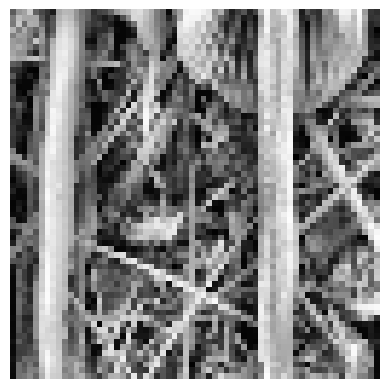

(64, 64, 3)


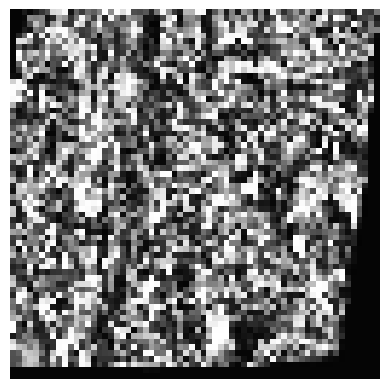

(64, 64, 3)


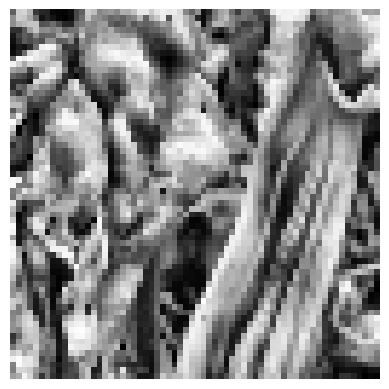

(64, 64, 3)


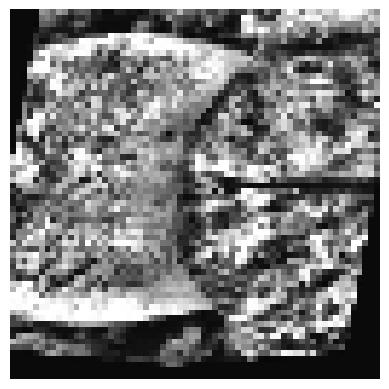

(64, 64, 3)


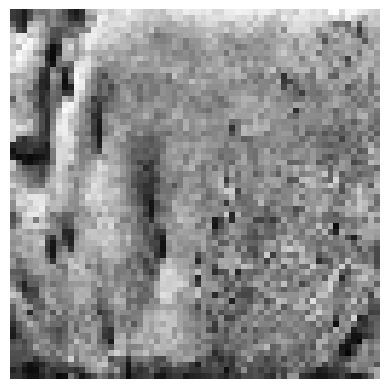

(64, 64, 3)


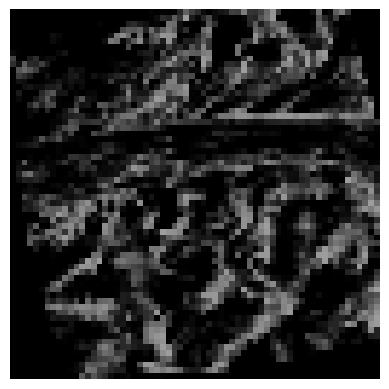

(64, 64, 3)


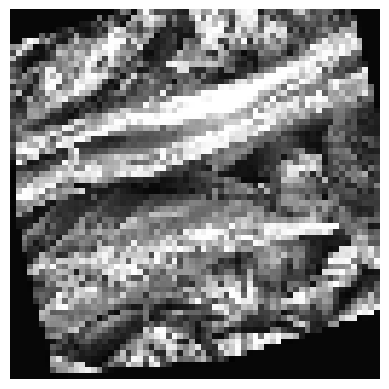

(64, 64, 3)


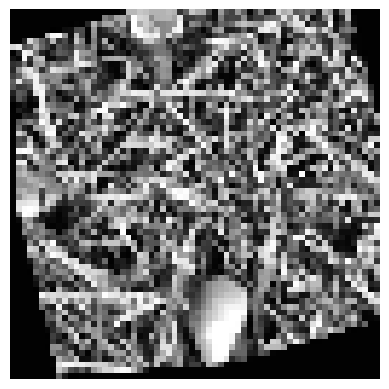

(64, 64, 3)


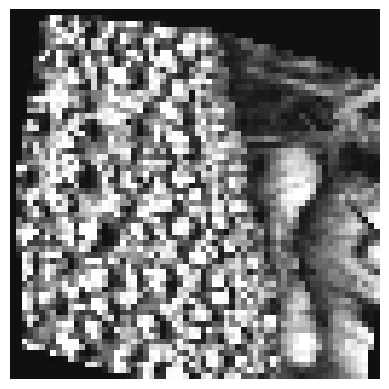

(64, 64, 3)


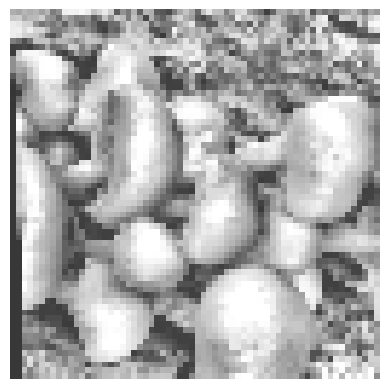

In [5]:
for x in X_train[9:19]:
    print(x.shape)
    img_fixed = x.astype(np.uint8)
    plt.imshow(img_fixed)
    plt.axis('off') 
    plt.show()

### 2.2. checking dataset balance

0
0    2868
1    1161
2     633
Name: count, dtype: int64


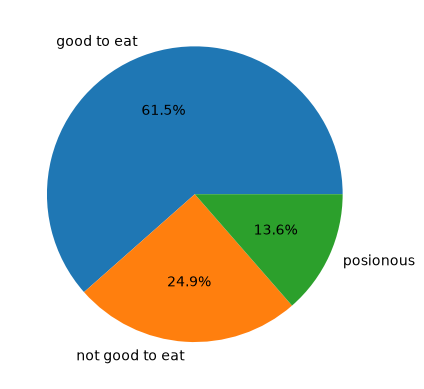

In [6]:
labels = {
    0: "good to eat",
    1: "not good to eat",
    2: "posionous"
}

_y = pd.DataFrame(y_train)
print(_y.value_counts())

d = dict(_y.value_counts())

plt.pie(x=d.values(), labels=labels.values(), autopct='%1.1f%%')

In [7]:
_y = pd.DataFrame(y_test)
_y.value_counts()

0
0    136
1     54
2     25
Name: count, dtype: int64

# 3. Training

### 3.1. defining `build_cnn()` funciton

In [8]:
def build_cnn(num_classes: int, config: dict) -> keras.Model:
    inputs = keras.Input(shape=(image_width, image_width, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.RandomFlip("horizontal")(x)

    for filters in config["filters"]:
        x = layers.Conv2D(filters, kernel_size=config["kernel_size"], padding="same", use_bias=not config["batch_norm"])(x)
        if config["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

        
    x = layers.Dropout(config["dropout"])(x)

    # ======== NEW ADDED ==== ======================
    for dense in config["dense"]:
        x = layers.Dense(dense, activation="relu")(x)
    # ======== ============== ======================

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=config["name"])

### 3.2. Actual Training

In [19]:
config = {
    "name": "Model_A_Baseline",
    "filters": [32, 64],
    "kernel_size": (3, 3),
    "batch_norm": False, 
    "dropout": 0,
    "dense": [32]
}

model_architecture = build_cnn(3, config)

**NOTE:**

I added a seperate optimizer to control the learning rate, because the defualt learning rate was too big, that the CNN only predict 1 label ALWAYS

In [26]:
optimizer = keras.optimizers.SGD(learning_rate=0.001) 
model_architecture.compile(optimizer=optimizer,  loss="SparseCategoricalCrossentropy", metrics=['accuracy'])

In [28]:
exper_1_history = model_architecture.fit(x=X_train, y=y_train, batch_size=16, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6152 - loss: 0.9164 - val_accuracy: 0.6152 - val_loss: 0.9165
Epoch 2/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6152 - loss: 0.9164 - val_accuracy: 0.6152 - val_loss: 0.9164
Epoch 3/10
 40/292 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6266 - loss: 0.8982

KeyboardInterrupt: 

# 4. Evaluation

In [12]:
from sklearn.metrics import classification_report, accuracy_score

In [13]:
exper_1_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [14]:
training_accuracy = exper_1_history.history['accuracy']
training_loss = exper_1_history.history['loss']

val_accuracy = exper_1_history.history['val_accuracy']
val_loss = exper_1_history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

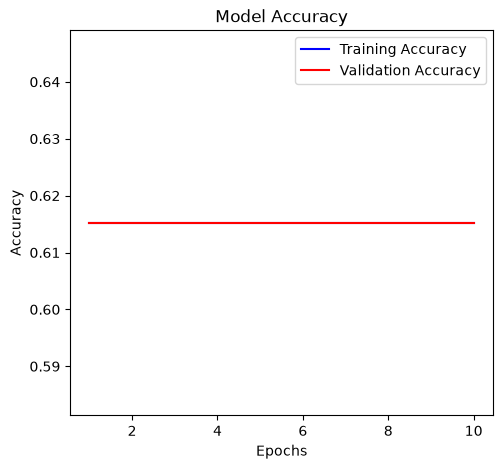

In [15]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, 'r-', label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

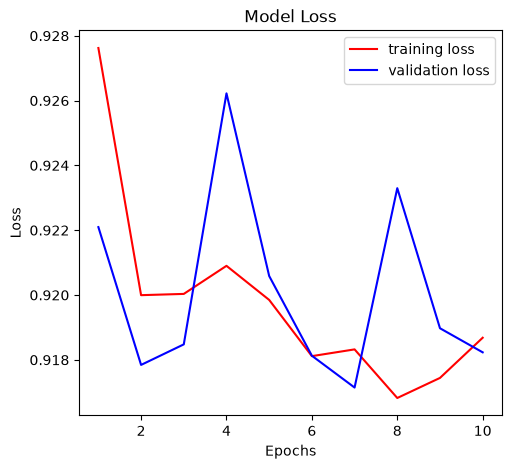

In [16]:
plt.figure(figsize=(12,5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_loss, '-r', label="training loss") 
plt.plot(epochs_range, val_loss, '-b', label="validation loss") 

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# 5. Testing

In [17]:
y_pred_args = exper_1_history.model.predict(X_test)
y_pred = np.argmax(y_pred_args, axis=1)
y_pred

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [18]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       136
           1       0.00      0.00      0.00        54
           2       0.00      0.00      0.00        25

    accuracy                           0.63       215
   macro avg       0.21      0.33      0.26       215
weighted avg       0.40      0.63      0.49       215



/Users/rashed/Documents/GitHub/Toxic-Mushroom-CNN/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rashed/Documents/GitHub/Toxic-Mushroom-CNN/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rashed/Documents/GitHub/Toxic-Mushroom-CNN/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co